# Perceptron Learning Implementation
# Deep Learning Lab

Final Weights : [0.2 0.1]
Final Bias : -0.20000000000000004

Predictions
[0 0]  ->  0
[0 1]  ->  0
[1 0]  ->  0
[1 1]  ->  1

Accuracy = 100.0 %

Decision Boundary:
0.20x1 + 0.10x2 + (-0.20) = 0


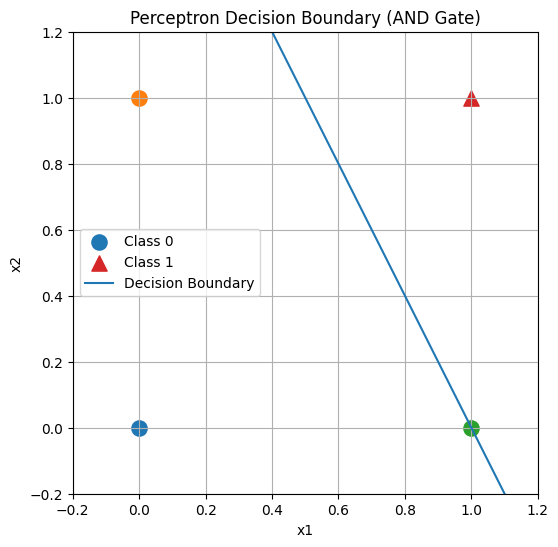

In [ ]:


import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Step Activation Function
# -------------------------------
def step_function(x):
    if x >= 0:
        return 1
    else:
        return 0


# -------------------------------
# Perceptron Training Function
# -------------------------------
def train_perceptron(X, y, lr=0.1, epochs=10):

    # Initialize weights and bias
    weights = np.zeros(X.shape[1])
    bias = 0

    # Training Loop
    for epoch in range(epochs):

        for i in range(len(X)):

            # Linear Combination
            linear_output = np.dot(X[i], weights) + bias

            # Activation Function
            y_pred = step_function(linear_output)

            # Error
            error = y[i] - y_pred

            # Weight Update Rule
            weights = weights + lr * error * X[i]

            # Bias Update
            bias = bias + lr * error

    return weights, bias


# -------------------------------
# Prediction Function
# -------------------------------
def predict(X, weights, bias):

    predictions = []

    for x in X:
        linear_output = np.dot(x, weights) + bias
        predictions.append(step_function(linear_output))

    return np.array(predictions)


# ======================================
# AND Gate Dataset
# ======================================

X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([
    0,
    0,
    0,
    1
])


# ======================================
# Train Model
# ======================================

weights, bias = train_perceptron(
    X,
    y,
    lr=0.1,
    epochs=10
)


# ======================================
# Predictions
# ======================================

predictions = predict(X, weights, bias)


# ======================================
# Results
# ======================================

print("Final Weights :", weights)
print("Final Bias :", bias)

print("\nPredictions")

for i in range(len(X)):
    print(X[i], " -> ", predictions[i])


# ======================================
# Accuracy
# ======================================

accuracy = np.mean(predictions == y) * 100

print("\nAccuracy =", accuracy,"%")



# ======================================
# Decision Boundary
# w1*x1 + w2*x2 + b = 0
# ======================================

print("\nDecision Boundary:")
print(f"{weights[0]:.2f}x1 + {weights[1]:.2f}x2 + ({bias:.2f}) = 0")


# ======================================
# Visualization
# ======================================

plt.figure(figsize=(6,6))

# Plot points
for i in range(len(X)):
    if y[i] == 0:
        plt.scatter(X[i,0], X[i,1], s=120, marker='o', label='Class 0' if i==0 else "")
    else:
        plt.scatter(X[i,0], X[i,1], s=120, marker='^', label='Class 1')


# Decision Boundary

x_values = np.linspace(-0.2,1.2,100)

if weights[1] != 0:
    y_values = -(weights[0]*x_values + bias)/weights[1]
    plt.plot(x_values,y_values,label="Decision Boundary")

plt.xlim(-0.2,1.2)
plt.ylim(-0.2,1.2)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Perceptron Decision Boundary (AND Gate)")
plt.grid(True)
plt.legend()

plt.show()

# LAB 2
# Multilayer Perceptron (MLP)
# Hyperparameter Tuning

In [ ]:

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# -----------------------------
# XOR Dataset
# -----------------------------

X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
], dtype=np.float32)

y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=np.float32)

# -----------------------------
# Hyperparameters
# -----------------------------

experiments = [
    ("sigmoid",0.01),
    ("sigmoid",0.1),
    ("relu",0.01),
    ("relu",0.1)
]

results=[]

# -----------------------------
# Run Experiments
# -----------------------------

for activation,lr in experiments:

    model=Sequential([
        Dense(4,input_shape=(2,),activation=activation),
        Dense(1,activation='sigmoid')
    ])

    optimizer=tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    history=model.fit(
        X,
        y,
        epochs=100,
        verbose=0
    )

    loss,acc=model.evaluate(X,y,verbose=0)

    results.append([activation,lr,loss,acc])

    print("--------------------------------")
    print("Activation :",activation)
    print("Learning Rate :",lr)
    print("Final Loss :",round(loss,4))
    print("Final Accuracy :",round(acc*100,2),"%")

# -----------------------------
# Predictions
# -----------------------------

print("\nPredictions\n")

pred=model.predict(X)

for i in range(len(X)):
    print(X[i]," -> ",round(float(pred[i]),3))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


--------------------------------
Activation : sigmoid
Learning Rate : 0.01
Final Loss : 0.6025
Final Accuracy : 100.0 %
--------------------------------
Activation : sigmoid
Learning Rate : 0.1
Final Loss : 0.073
Final Accuracy : 100.0 %
--------------------------------
Activation : relu
Learning Rate : 0.01
Final Loss : 0.4888
Final Accuracy : 100.0 %
--------------------------------
Activation : relu
Learning Rate : 0.1
Final Loss : 0.0042
Final Accuracy : 100.0 %

Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
[0. 0.]  ->  0.014
[0. 1.]  ->  0.999
[1. 0.]  ->  0.999
[1. 1.]  ->  0.001


/tmp/ipykernel_1665/3723605474.py:83: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(X[i]," -> ",round(float(pred[i]),3))


#Plot Loss Curve


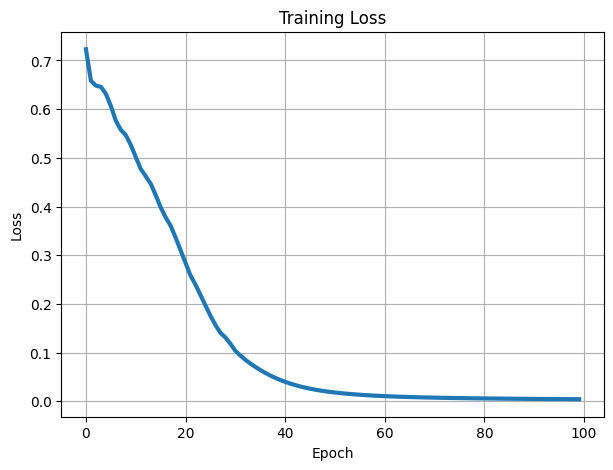

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(history.history['loss'],linewidth=3)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.show()

#Plot Accuracy Curve

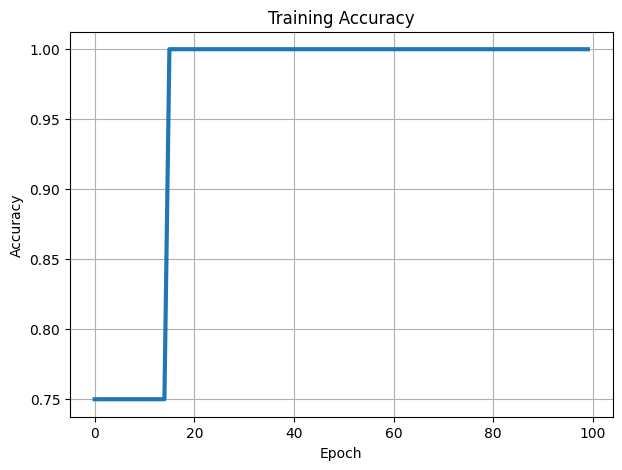

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(history.history['accuracy'],linewidth=3)

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

#Hyperparameter Comparison Table

In [ ]:
import pandas as pd

df=pd.DataFrame(results,
                columns=[
                    "Activation",
                    "Learning Rate",
                    "Final Loss",
                    "Final Accuracy"
                ])

df["Final Accuracy"]=df["Final Accuracy"]*100

print(df)

  Activation  Learning Rate  Final Loss  Final Accuracy
0    sigmoid           0.01    0.602513           100.0
1    sigmoid           0.10    0.073026           100.0
2       relu           0.01    0.488795           100.0
3       relu           0.10    0.004222           100.0


LAB 3 : Advanced Hyperparameter Optimization


In [8]:
!pip -q install scikeras
!pip install scikit-learn==1.5.2 scikeras==0.13.0 -q

In [11]:
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Dataset
iris = load_iris()
X = iris.data
y = iris.target

# Normalize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Hyperparameters
hidden_units_list = [8, 16]
learning_rates = [0.001, 0.01]
dropout_rates = [0.0, 0.3]
batch_sizes = [16, 32]

results = []

trial = 1

for hidden in hidden_units_list:
    for lr in learning_rates:
        for drop in dropout_rates:
            for batch in batch_sizes:

                model = tf.keras.Sequential([
                    tf.keras.layers.Dense(hidden, activation='relu', input_shape=(4,)),
                    tf.keras.layers.Dropout(drop),
                    tf.keras.layers.Dense(3, activation='softmax')
                ])

                optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

                model.compile(
                    optimizer=optimizer,
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy']
                )

                history = model.fit(
                    X_train,
                    y_train,
                    epochs=50,
                    batch_size=batch,
                    verbose=0,
                    validation_data=(X_test, y_test)
                )

                train_loss = history.history['loss'][-1]
                val_acc = history.history['val_accuracy'][-1]

                overfit = "Yes" if train_loss < 0.05 and val_acc < 0.95 else "No"

                results.append([
                    trial,
                    hidden,
                    lr,
                    drop,
                    batch,
                    round(train_loss,4),
                    round(val_acc*100,2),
                    overfit
                ])

                trial += 1

results = pd.DataFrame(results, columns=[
    "Trial",
    "Hidden Units",
    "Learning Rate",
    "Dropout",
    "Batch Size",
    "Training Loss",
    "Validation Accuracy (%)",
    "Overfitting"
])

print(results)

best = results.sort_values("Validation Accuracy (%)", ascending=False).head(1)

print("\nBest Configuration")
print(best)

    Trial  Hidden Units  Learning Rate  Dropout  Batch Size  Training Loss  \
0       1             8          0.001      0.0          16         0.3719   
1       2             8          0.001      0.0          32         0.6253   
2       3             8          0.001      0.3          16         0.5051   
3       4             8          0.001      0.3          32         0.9207   
4       5             8          0.010      0.0          16         0.0583   
5       6             8          0.010      0.0          32         0.0833   
6       7             8          0.010      0.3          16         0.1899   
7       8             8          0.010      0.3          32         0.1738   
8       9            16          0.001      0.0          16         0.3292   
9      10            16          0.001      0.0          32         0.4428   
10     11            16          0.001      0.3          16         0.3741   
11     12            16          0.001      0.3          32     

#DNN-lab4

In [12]:
# ===========================================
# CELL 1 : Import Libraries & Load Dataset
# ===========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import random

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load CSV files
train = pd.read_csv("mnist_train.csv")
test = pd.read_csv("mnist_test.csv")

print("Training Dataset Shape :", train.shape)
print("Testing Dataset Shape  :", test.shape)

# Display first 5 rows
train.head()

Training Dataset Shape : (5164, 785)
Testing Dataset Shape  : (5200, 785)


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,9,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Training Images : (5164, 784)
Training Labels : (5164,)
Testing Images  : (5200, 784)
Testing Labels  : (5200,)


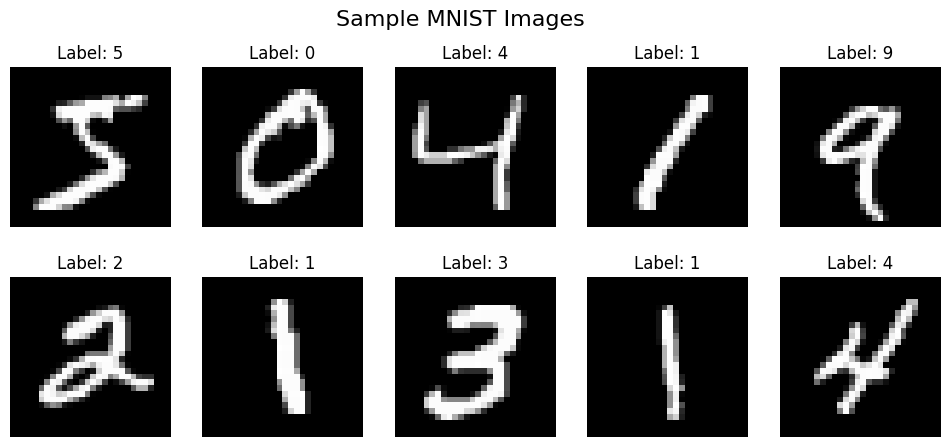

In [13]:
# ===========================================
# CELL 2 : Data Preprocessing
# ===========================================

# Separate labels and pixel values
X_train = train.iloc[:, 1:].values
y_train = train.iloc[:, 0].values

X_test = test.iloc[:, 1:].values
y_test = test.iloc[:, 0].values

# Normalize pixel values (0-255 -> 0-1)
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)
print("Testing Images  :", X_test.shape)
print("Testing Labels  :", y_test.shape)

# Display first 10 handwritten digits
plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.suptitle("Sample MNIST Images", fontsize=16)
plt.show()

In [14]:
# ===========================================
# CELL 3 : Build Deep Neural Network (DNN)
# ===========================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Build Model
model = Sequential()

# Input Layer + Hidden Layer 1
model.add(Dense(128, activation='relu', input_shape=(784,)))

# Hidden Layer 2
model.add(Dense(64, activation='relu'))

# Output Layer (10 digits)
model.add(Dense(10, activation='softmax'))

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display Model Summary
model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# ===========================================
# CELL 4 : Train the Model
# ===========================================

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7686 - loss: 0.7897 - val_accuracy: 0.8587 - val_loss: nan
Epoch 2/5
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9187 - loss: 0.2870 - val_accuracy: 0.9032 - val_loss: nan
Epoch 3/5
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9438 - loss: 0.1967 - val_accuracy: 0.9013 - val_loss: nan
Epoch 4/5
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9610 - loss: 0.1482 - val_accuracy: 0.9148 - val_loss: nan
Epoch 5/5
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9710 - loss: 0.1082 - val_accuracy: 0.9409 - val_loss: nan


In [16]:
# ===========================================
# CELL 5 : Evaluate the Model
# ===========================================

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("="*40)
print("MODEL PERFORMANCE")
print("="*40)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy*100:.2f}%")

MODEL PERFORMANCE
Test Loss     : nan
Test Accuracy : 90.56%


163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


<Figure size 800x800 with 0 Axes>

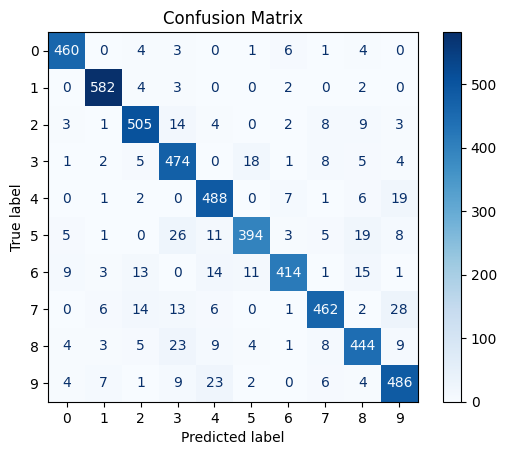

In [17]:
# ===========================================
# CELL 6 : Confusion Matrix
# ===========================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict
y_pred = model.predict(X_test)

# Convert probabilities to labels
y_pred_labels = np.argmax(y_pred, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_labels)

plt.figure(figsize=(8,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

Total Misclassified Images : 491


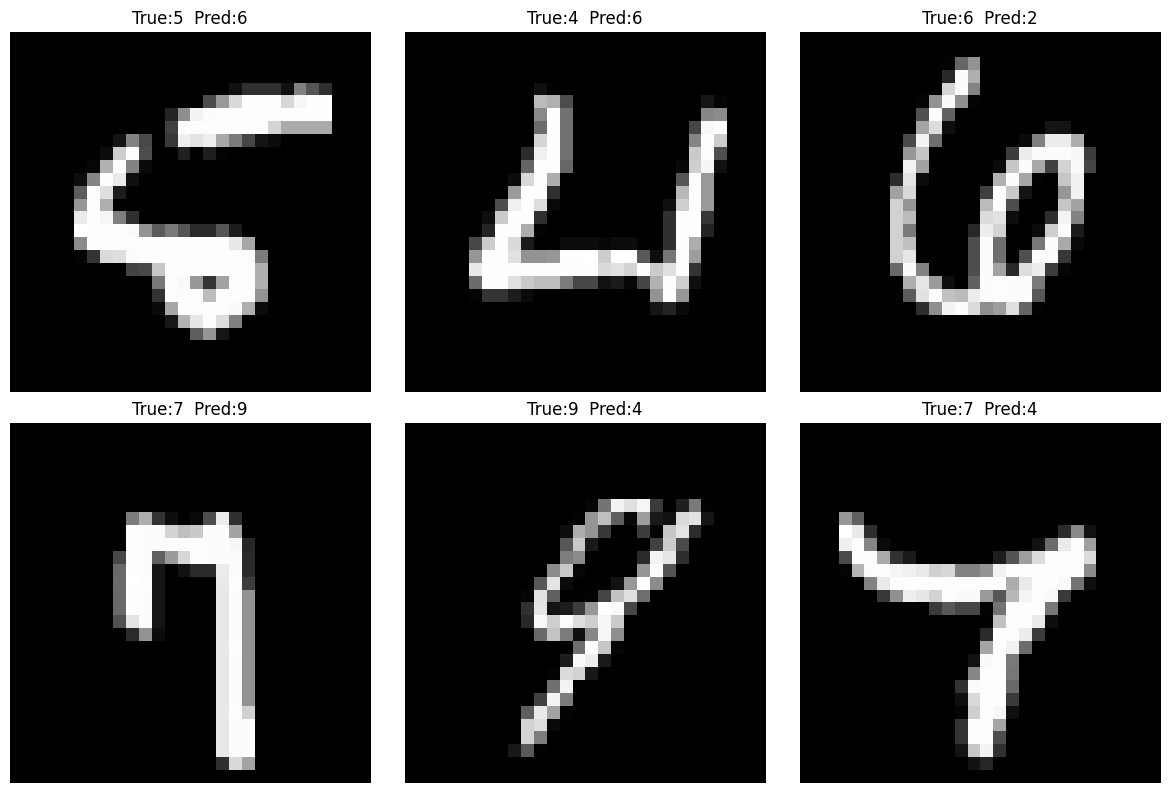

In [18]:
# ===========================================
# CELL 7 : Misclassified Images
# ===========================================

misclassified = np.where(y_test != y_pred_labels)[0]

print("Total Misclassified Images :", len(misclassified))

plt.figure(figsize=(12,8))

for i,index in enumerate(misclassified[:6]):

    plt.subplot(2,3,i+1)

    plt.imshow(X_test[index].reshape(28,28),
               cmap='gray')

    plt.title(f"True:{y_test[index]}  Pred:{y_pred_labels[index]}")

    plt.axis('off')

plt.tight_layout()
plt.show()

Enter a digit (0-9): 5


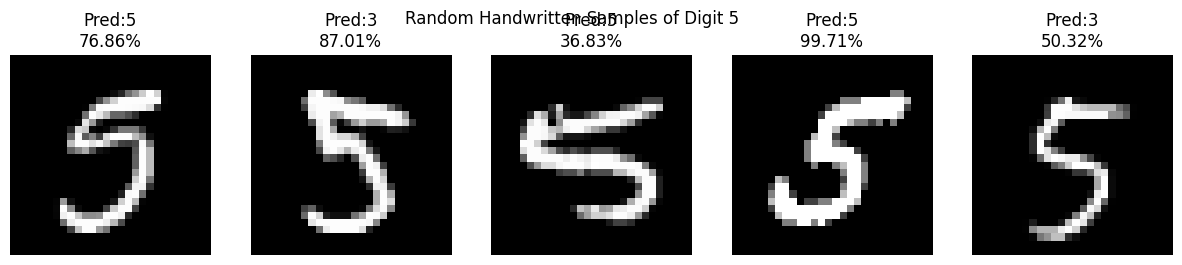

In [20]:


digit = int(input("Enter a digit (0-9): "))

indices = np.where(y_test == digit)[0]

if len(indices)==0:

    print("Digit not found!")

else:

    random_images = np.random.choice(indices,5)

    plt.figure(figsize=(15,3))

    for i,index in enumerate(random_images):

        image = X_test[index].reshape(28,28)

        prediction = model.predict(
            X_test[index].reshape(1,784),
            verbose=0
        )

        pred = np.argmax(prediction)

        confidence = np.max(prediction)*100

        plt.subplot(1,5,i+1)

        plt.imshow(image,cmap='gray')

        plt.title(f"Pred:{pred}\n{confidence:.2f}%")

        plt.axis('off')

    plt.suptitle(f"Random Handwritten Samples of Digit {digit}")

    plt.show()

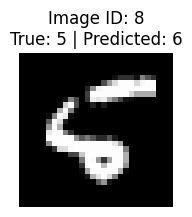

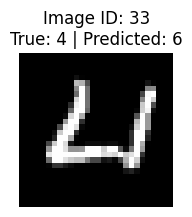

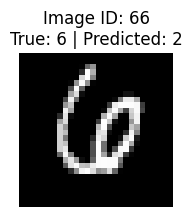

In [22]:


misclassified = np.where(y_test != y_pred_labels)[0]

for idx in misclassified[:3]:
    plt.figure(figsize=(2,2))
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"Image ID: {idx}\nTrue: {y_test[idx]} | Predicted: {y_pred_labels[idx]}")
    plt.axis('off')
    plt.show()